In [1]:
# ==========================================
# الخلية 0: تثبيت المكتبات اللازمة والاستيراد
# ==========================================
!pip install -q transformers datasets accelerate scikit-learn pandas seaborn matplotlib torch

import os, re, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils import resample
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("✅ تم تثبيت واستيراد جميع المكتبات بنجاح.")

✅ تم تثبيت واستيراد جميع المكتبات بنجاح.


In [2]:
# ==========================================
# الخلية 1: توليد التسميات باستخدام القواعد الهرمية
# ==========================================
def generate_repo_labels(df):
    """
    توليد التسميات بناءً على topics مع أولوية هرمية.
    الأولوية: AI > Data Science > Mobile > DevOps > Web
    """
    HIERARCHY = ['AI', 'Data Science', 'Mobile', 'DevOps', 'Web']
    FULL_NAMES = {
        'AI': 'AI / Machine Learning', 'Data Science': 'Data Science',
        'Mobile': 'Mobile Applications', 'DevOps': 'DevOps', 'Web': 'Web Development'
    }
    KEYWORDS = {
        'AI': ['machine-learning', 'deep-learning', 'neural-network', 'tensorflow',
               'pytorch', 'llm', 'transformer', 'artificial-intelligence', 'nlp', 'keras'],
        'Data Science': ['data-science', 'pandas', 'numpy', 'data-analysis', 'visualization',
                         'matplotlib', 'jupyter', 'data-mining', 'big-data', 'sql'],
        'Mobile': ['android', 'ios', 'mobile', 'flutter', 'react-native', 'swift',
                   'kotlin', 'xamarin', 'mobile-app'],
        'DevOps': ['docker', 'kubernetes', 'ci-cd', 'devops', 'aws', 'azure', 'gcp',
                   'terraform', 'ansible', 'jenkins', 'cloud'],
        'Web': ['react', 'frontend', 'backend', 'web', 'javascript', 'vue', 'angular',
                'nodejs', 'express', 'django', 'flask', 'html', 'css', 'rest-api']
    }

    def classify_row(row):
        topics = row.get('topics_list', [])
        if isinstance(topics, str):
            try: topics = eval(topics)
            except: topics = [t.strip() for t in topics.replace('|', ',').split(',') if t.strip()]

        topics_lower = [t.lower() for t in topics]
        matched = {cat: sum(1 for kw in kws if kw.lower() in topics_lower)
                   for cat, kws in KEYWORDS.items()
                   if any(kw.lower() in topics_lower for kw in kws)}

        if not matched: return None, 0.0, "No match"

        for cat in HIERARCHY:
            if cat in matched:
                conf = min(0.95, (matched[cat] / len(KEYWORDS[cat])) * 2 + 0.5)
                return FULL_NAMES[cat], round(conf, 2), f"Matched {matched[cat]} keywords for {FULL_NAMES[cat]}"
        return None, 0.0, "Fallback"

    results = df.apply(classify_row, axis=1)
    df['label'] = [r[0] for r in results]
    return df[['name', 'description', 'readme', 'topics_list', 'label']]



In [4]:
df_raw = pd.read_csv('/content/cleaned_data.csv')
df_labeled = generate_repo_labels(df_raw)
df_labeled.dropna(subset=['label'], inplace=True)
print("تم توليد التسميات بنجاح.")
print(df_labeled['label'].value_counts())

تم توليد التسميات بنجاح.
label
AI / Machine Learning    239
DevOps                   113
Mobile Applications       52
Web Development           34
Data Science              21
Name: count, dtype: int64


/tmp/ipykernel_1190/1108416999.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled.dropna(subset=['label'], inplace=True)


In [5]:
# ==========================================
# الخلية 2: دمج الفئات لتصبح 3 + التقسيم الطبقي + تعريف القواميس
# ==========================================
def merge_and_split(df):
    """دمج الفئات وتقسيم البيانات مع تعريف ثابت لـ label2id"""
    df_m = df.copy()

    # الدمج: Data Science → AI, DevOps → Web
    df_m['label'] = df_m['label'].replace({
        'Data Science': 'AI / Machine Learning',
        'DevOps': 'Web Development'
    })

    # ✅ تعريف ثابت وموحد للقواميس (مهم جداً لتجنب أخطاء CUDA)
    global label2id, id2label
    label2id = {
        'AI / Machine Learning': 0,
        'Mobile Applications': 1,
        'Web Development': 2
    }
    id2label = {v: k for k, v in label2id.items()}

    # حساب الأوزان الأولية
    from sklearn.utils.class_weight import compute_class_weight
    weights = compute_class_weight('balanced', classes=np.unique(df_m['label']), y=df_m['label'])
    global class_weights
    class_weights = dict(enumerate(weights))

    # تحويل التسميات لأرقام
    df_m['label_id'] = df_m['label'].map(label2id)

    # التقسيم الطبقي 70/15/15
    train_df, temp_df = train_test_split(
        df_m, test_size=0.30, stratify=df_m['label'], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
    )

    print("📊 التوزيع الأصلي:")
    print(df_m['label'].value_counts())
    print(f"\n⚖️  الأوزان الأولية: {class_weights}")
    print(f"📈 التقسيم: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

    return train_df, val_df, test_df



In [6]:
# 📌 شغّل هذا الكود في نهاية الخلية 2:
train_df, val_df, test_df = merge_and_split(df_labeled)

📊 التوزيع الأصلي:
label
AI / Machine Learning    260
Web Development          147
Mobile Applications       52
Name: count, dtype: int64

⚖️  الأوزان الأولية: {0: np.float64(0.5884615384615385), 1: np.float64(2.9423076923076925), 2: np.float64(1.0408163265306123)}
📈 التقسيم: Train=321 | Val=69 | Test=69


In [7]:
# ==========================================
# الخلية 3: تنظيف النصوص وتحويلها لـ HuggingFace Dataset (مصححة)
# ==========================================
def prepare_datasets_fixed(train_df, val_df, test_df, label2id, max_length=512):
    """
    تنظيف النصوص، التجزئة، وتحويلها لـ Dataset جاهز.
    ✅ التصحيح: استخدام label2id خارجي ثابت لتجنب تضارب التسميات
    """
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

    def clean_text(t):
        if not isinstance(t, str): return ""
        t = re.sub(r'http\S+|www\S+', '', t)
        t = re.sub(r'!\[.*?\]\(.*?\)', '', t)
        t = re.sub(r'<[^>]+>', ' ', t)
        t = re.sub(r'```[\s\S]*?```', ' ', t)
        t = re.sub(r'[^\w\s.,!?;:\-\']', ' ', t)
        return re.sub(r'\s+', ' ', t).strip()

    def preprocess(df):
        df = df.copy()
        # دمج الوصف + README
        df['clean_text'] = df['description'].fillna('') + " [SEP] " + df['readme'].fillna('')
        df['clean_text'] = df['clean_text'].apply(clean_text)

        # ✅ استخدام label2id الخارجي الثابت (مهم جداً)
        df['label_id'] = df['label'].map(label2id)
        df = df.dropna(subset=['label_id'])  # إزالة أي صفوف غير صالحة
        df['label_id'] = df['label_id'].astype(int)

        return df[['clean_text', 'label_id']]

    def create_ds(df):
        ds = Dataset.from_pandas(preprocess(df))
        return ds.map(
            lambda ex: tokenizer(ex['clean_text'], truncation=True, padding='max_length', max_length=max_length),
            batched=True, remove_columns=['clean_text']
        ).rename_column('label_id', 'labels')

    return create_ds(train_df), create_ds(val_df), create_ds(test_df), tokenizer



In [8]:
train_ds, val_ds, test_ds, tokenizer = prepare_datasets_fixed(train_df, val_df, test_df, label2id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/321 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

In [9]:
# ==========================================
# الخلية 4: Random Oversampling لمجموعة التدريب فقط
# ==========================================
def oversample_train(train_df, target_col='label'):
    """
    رفع عينات Mobile و Web صناعياً لتحقيق توازن أفضل.
    """
    print("📊 قبل Oversampling:")
    print(train_df[target_col].value_counts())

    maj = train_df[train_df[target_col] == 'AI / Machine Learning']
    mob = train_df[train_df[target_col] == 'Mobile Applications']
    web = train_df[train_df[target_col] == 'Web Development']

    # رفع Mobile و Web إلى 200 عينة لكل منهما
    mob_os = resample(mob, replace=True, n_samples=200, random_state=42)
    web_os = resample(web, replace=True, n_samples=200, random_state=42)

    train_balanced = pd.concat([maj, mob_os, web_os])

    print("\n📊 بعد Oversampling:")
    print(train_balanced[target_col].value_counts())
    return train_balanced



In [10]:
train_balanced_df = oversample_train(train_df)
train_ds_balanced, _, _, _ = prepare_datasets_fixed(train_balanced_df, val_df, test_df, label2id)

📊 قبل Oversampling:
label
AI / Machine Learning    182
Web Development          103
Mobile Applications       36
Name: count, dtype: int64

📊 بعد Oversampling:
label
Mobile Applications      200
Web Development          200
AI / Machine Learning    182
Name: count, dtype: int64


Map:   0%|          | 0/582 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

In [11]:
# ==========================================
# الخلية 5: تعريف Focal Loss و Trainer المخصص + تحميل النموذج
# ==========================================

# تعريف Focal Loss
class FocalLoss(nn.Module):
    """Focal Loss للتركيز على العينات الصعبة والأقلية"""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        fl = ((1 - pt) ** self.gamma) * ce
        return fl.mean() if self.reduction == 'mean' else fl.sum() if self.reduction == 'sum' else fl

# تعريف Trainer المخصص
class FocalTrainer(Trainer):
    """Trainer مخصص يحقن Focal Loss"""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        logits = model(**inputs).logits
        loss = FocalLoss(alpha=self.class_weights.to(logits.device), gamma=2.0)(logits, labels)
        return (loss, {"logits": logits}) if return_outputs else loss

# تحميل النموذج
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# تحويل أوزان الفئات لـ Tensor
weights_tensor = torch.tensor([class_weights[i] for i in range(3)], dtype=torch.float32)

print("✅ تم تحميل النموذج وتهيئة Focal Loss.")
print(f"📊 عدد البارامترات: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ تم تحميل النموذج وتهيئة Focal Loss.
📊 عدد البارامترات: 66,955,779


🚀 بدء التدريب...


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.247426,0.341233,0.560670,0.536232
2,0.079334,0.770582,0.715343,0.797101
3,0.008127,0.594328,0.739035,0.826087
4,0.001313,0.566485,0.751322,0.840580
5,0.001060,0.497955,0.766796,0.826087
6,0.000328,0.507443,0.777778,0.840580
7,0.000247,0.513158,0.803893,0.869565
8,0.000155,0.546185,0.764164,0.826087
9,0.000179,0.556589,0.764164,0.826087
10,0.000162,0.561057,0.764164,0.826087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



🎯 حساب العتبات المثلى على Validation Set...


✅ العتبات المثلى: {0: np.float64(0.49999999999999994), 1: np.float64(0.2), 2: np.float64(0.44999999999999996)}

📊 التقييم النهائي على Test Set...



📋 CLASSIFICATION REPORT:
                       precision    recall  f1-score   support

AI / Machine Learning       0.88      0.92      0.90        39
  Mobile Applications       0.75      0.75      0.75         8
      Web Development       0.85      0.77      0.81        22

             accuracy                           0.86        69
            macro avg       0.83      0.82      0.82        69
         weighted avg       0.85      0.86      0.85        69



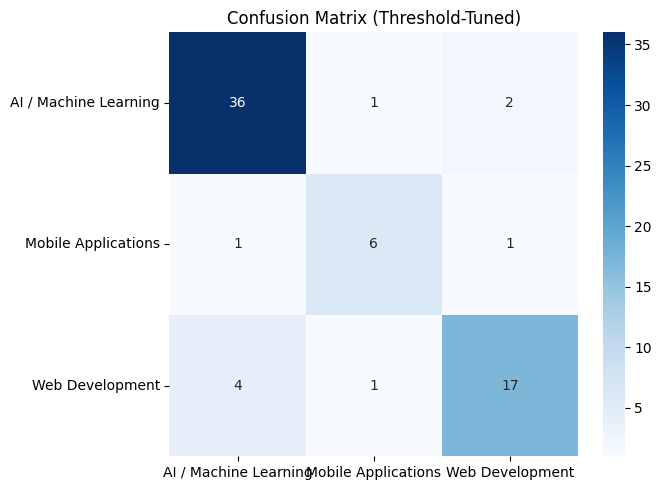


✅ Final Macro F1: 0.8198
✅ Final Accuracy: 0.8551


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 تم حفظ النموذج النهائي في: ./best_model_thresholded


In [12]:
# ==========================================
# الخلية 6: التدريب، ضبط العتبات، والتقييم النهائي
# ==========================================

# دالة حساب المقاييس
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average='macro', zero_division=0),
        "accuracy": accuracy_score(labels, preds)
    }

# إعدادات التدريب
args = TrainingArguments(
    output_dir="./github_distilbert_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=15,
    weight_decay=0.05,
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_steps=10,
    report_to="none",
    warmup_steps=50,
    save_total_limit=2
)

# إنشاء Trainer
trainer = FocalTrainer(
    class_weights=weights_tensor,
    model=model,
    args=args,
    train_dataset=train_ds_balanced,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("🚀 بدء التدريب...")
trainer.train()

# 🔍 حساب Optimal Thresholds على Validation Set
print("\n🎯 حساب العتبات المثلى على Validation Set...")
preds_val = trainer.predict(val_ds)
probs_val = torch.softmax(torch.tensor(preds_val.predictions), dim=-1).numpy()
labels_val = preds_val.label_ids

thresholds = {}
for cls in range(3):
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.2, 0.8, 0.05):
        p = (probs_val[:, cls] >= t).astype(int)
        if p.sum() > 0:
            f = f1_score((labels_val == cls).astype(int), p, zero_division=0)
            if f > best_f1:
                best_f1, best_t = f, t
    thresholds[cls] = best_t
print(f"✅ العتبات المثلى: {thresholds}")

# 📊 التقييم النهائي على Test Set مع تطبيق العتبات
print("\n📊 التقييم النهائي على Test Set...")
preds_test = trainer.predict(test_ds)
probs_test = torch.softmax(torch.tensor(preds_test.predictions), dim=-1).numpy()
y_true = preds_test.label_ids

y_pred_tuned = []
for i in range(len(probs_test)):
    passed = [c for c in range(3) if probs_test[i, c] >= thresholds[c]]
    y_pred_tuned.append(max(passed, key=lambda c: probs_test[i, c]) if passed else np.argmax(probs_test[i]))

target_names = [id2label[c] for c in range(3)]
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred_tuned, target_names=target_names, zero_division=0))

# رسم Confusion Matrix
cm = confusion_matrix(y_true, y_pred_tuned)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Threshold-Tuned)')
plt.tight_layout()
plt.show()

# طباعة النتائج النهائية
final_f1 = f1_score(y_true, y_pred_tuned, average='macro', zero_division=0)
final_acc = accuracy_score(y_true, y_pred_tuned)
print(f"\n✅ Final Macro F1: {final_f1:.4f}")
print(f"✅ Final Accuracy: {final_acc:.4f}")

# حفظ النموذج
trainer.save_model("./best_model_thresholded")
tokenizer.save_pretrained("./best_model_thresholded")
print("💾 تم حفظ النموذج النهائي في: ./best_model_thresholded")